# Panel-level carrier-set agreement: v3, v3 cactus-only, p82 — all vs GrENE-Net

For each panel, compare per-SNP **founder carrier sets** (boolean 0/1 per founder per SNP)
against the GrENE-Net VCF carrier sets at matched (chrom, pos, REF, ALT) on Chr1.

This is **panel level** — the cn_var matrix that AF projection multiplies `h` against.
NOT the EM output. The disagreements measured here are present BEFORE any inference happens.

| panel | source | F overlap with GN |
|---|---|---|
| **v3 (all 231)** | cactus-pangenome (80) + PanGenie short-read (151) | 231 |
| **v3 cactus-only** | restrict v3 to the 80 cactus founders | 80 |
| **p82** | pure cactus pangenome of 82 long-read assemblies (no PanGenie) | 80 (overlapping with GN) |

**Caveat on exact-match %**: comparing exact-match rates across panels with different F is misleading. A panel with F=231 must agree on 231 cells per record to be "exact"; F=80 must agree on 80 cells. So 33% (v3, F=231) vs 54% (v3 cactus-only, F=80) is NOT apples-to-apples. The **per-cell match rate** below IS F-comparable.

**Two key ratio definitions:**

- **cells O/U** — across all (founder × SNP) cells, count of "panel says carrier, GN says non" vs "panel says non, GN says carrier". Per-cell asymmetry.
- **record O/U** — for each record, classify by NET direction (more cells over → record-over, more cells under → record-under). Per-record direction asymmetry.

These can diverge: a panel can have balanced CELLS (cell O/U ≈ 1) but skewed RECORDS (e.g., over-call broadly across many records, under-call deeply at fewer records).


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ROOT = Path('/global/scratch/users/tbellg/kmate')

# Load 3 panel comparisons (drop task 4 = v2 — same as GN, not informative)
results = []
for t in [1, 2, 3]:
    f = ROOT / f'scratch/panel_cmp_task{t}.json'
    if f.exists():
        results.append(json.loads(f.read_text()))

df = pd.DataFrame(results)
df['exact_pct']      = 100 * df['exact'] / df['n_matched']
df['cell_O_U_ratio'] = df['cells_over'] / df['cells_under'].clip(lower=1)
df['rec_O_U_ratio']  = df['rec_over']  / df['rec_under'].clip(lower=1)
df['mean_over_cells_per_over_record']  = df['cells_over']  / df['rec_over'].clip(lower=1)
df['mean_under_cells_per_under_record'] = df['cells_under'] / df['rec_under'].clip(lower=1)
# F-comparable per-cell metric
df['total_cells']        = df['F'] * df['n_matched']
df['disagree_cells']     = df['cells_over'] + df['cells_under']
df['cell_match_pct']     = 100 * (1 - df['disagree_cells'] / df['total_cells'])
df['cell_disagree_pct']  = 100 * df['disagree_cells'] / df['total_cells']
print(df[['label','n_matched','F','total_cells','exact_pct','cell_match_pct',
          'cell_O_U_ratio','rec_O_U_ratio',
          'mean_over_cells_per_over_record','mean_under_cells_per_under_record']].to_string(index=False, float_format='%.3f'))


                 label  n_matched   F  total_cells  exact_pct  cell_match_pct  cell_O_U_ratio  rec_O_U_ratio  mean_over_cells_per_over_record  mean_under_cells_per_under_record
          v3 (all 231)     436927 231    100930137     33.169          98.652           1.849          1.941                            5.115                              5.369
   v3 cactus-only (80)     436927  80     34954160     54.365          98.947           1.314          1.530                            2.023                              2.356
p82 (82 cactus, no PG)     452402  80     36192160     51.714          98.714           0.950          1.431                            2.046                              3.081


## Plot 1 — Composition of matched SNP records per panel (with exact counts)

Stacked bars showing: exact match / net over-call / net under-call / net-zero. Each segment annotated with EXACT record count (not just %).


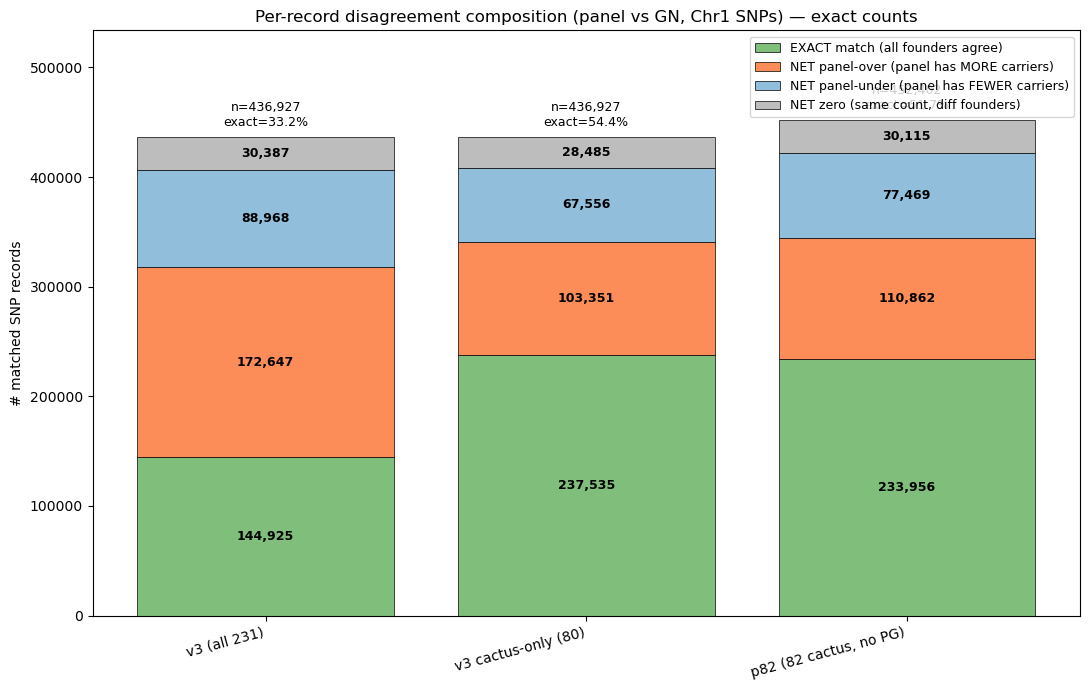

In [2]:
fig, ax = plt.subplots(figsize=(11, 7))
labels = df['label'].tolist()
x = np.arange(len(labels))
exact   = df['exact'].values
over    = df['rec_over'].values
under   = df['rec_under'].values
netzero = df['rec_net_zero'].values

bottom = np.zeros(len(labels))
for height, color, lab in [
    (exact,   '#7fbf7b', 'EXACT match (all founders agree)'),
    (over,    '#fc8d59', 'NET panel-over (panel has MORE carriers)'),
    (under,   '#91bfdb', 'NET panel-under (panel has FEWER carriers)'),
    (netzero, '#bdbdbd', 'NET zero (same count, diff founders)'),
]:
    bars = ax.bar(x, height, bottom=bottom, color=color, label=lab, edgecolor='black', linewidth=0.5)
    # Annotate each segment with its exact count, centered in the segment
    for xi, (h, b) in enumerate(zip(height, bottom)):
        if h > 0:
            ax.text(xi, b + h/2, f'{int(h):,}', ha='center', va='center',
                    fontsize=9, color='black', fontweight='bold')
    bottom += height

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('# matched SNP records')
ax.set_title('Per-record disagreement composition (panel vs GN, Chr1 SNPs) — exact counts')
ax.legend(loc='upper right', fontsize=9)

for xi, (e, total) in enumerate(zip(exact, df['n_matched'].values)):
    ax.text(xi, total + total*0.015, f'n={total:,}\nexact={100*e/total:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(df['n_matched'].values) * 1.18)
plt.tight_layout()
plt.show()


## Plot 2 — Same composition, normalized to %

Easier to compare across panels with different total record counts. **Note**: exact-match % is per-record (depends on F); see Plot 3 right panel for F-comparable per-cell match rate.


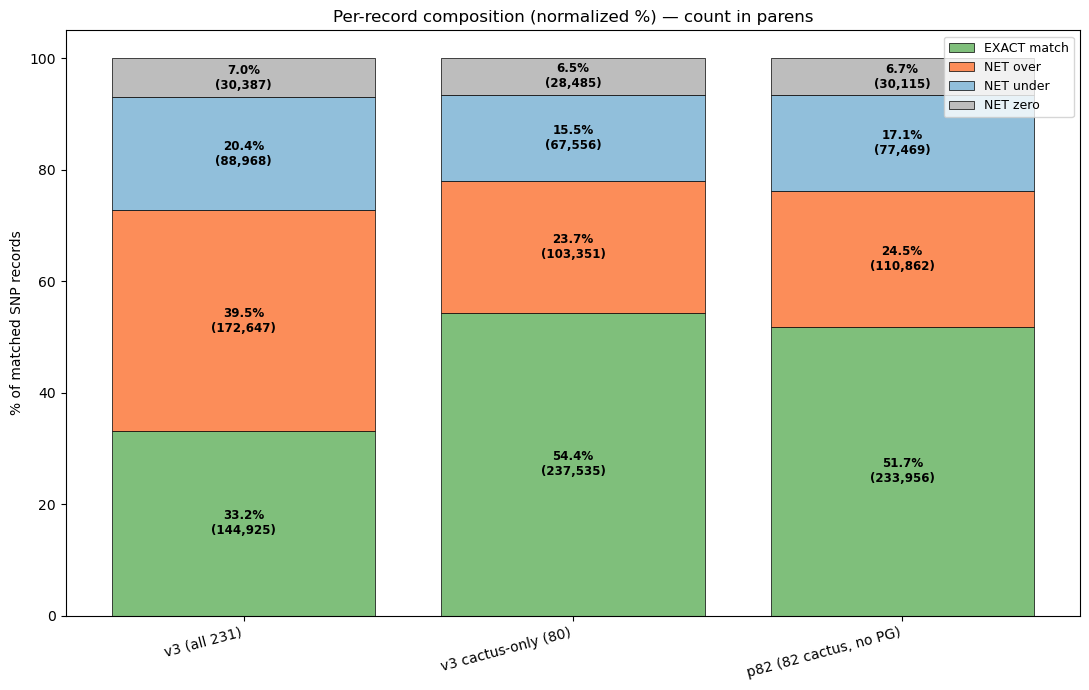

In [3]:
fig, ax = plt.subplots(figsize=(11, 7))
exact_pct   = 100 * exact / df['n_matched'].values
over_pct    = 100 * over / df['n_matched'].values
under_pct   = 100 * under / df['n_matched'].values
netzero_pct = 100 * netzero / df['n_matched'].values

bottom = np.zeros(len(labels))
for h_pct, h_count, color, lab in [
    (exact_pct,   exact,   '#7fbf7b', 'EXACT match'),
    (over_pct,    over,    '#fc8d59', 'NET over'),
    (under_pct,   under,   '#91bfdb', 'NET under'),
    (netzero_pct, netzero, '#bdbdbd', 'NET zero'),
]:
    ax.bar(x, h_pct, bottom=bottom, color=color, label=lab, edgecolor='black', linewidth=0.5)
    for xi, (hp, hc, b) in enumerate(zip(h_pct, h_count, bottom)):
        if hp > 1.5:
            ax.text(xi, b + hp/2, f'{hp:.1f}%\n({int(hc):,})',
                    ha='center', va='center', fontsize=8.5, color='black', fontweight='bold')
    bottom += h_pct
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('% of matched SNP records')
ax.set_ylim(0, 105)
ax.set_title('Per-record composition (normalized %) — count in parens')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


## Plot 3 — Cell-level totals + F-comparable per-cell match rate

**Right panel is the F-comparable metric**: per-cell match rate divides by total cells (F × n_matched), so a panel with more founders isn't penalized for having more cells to disagree on.


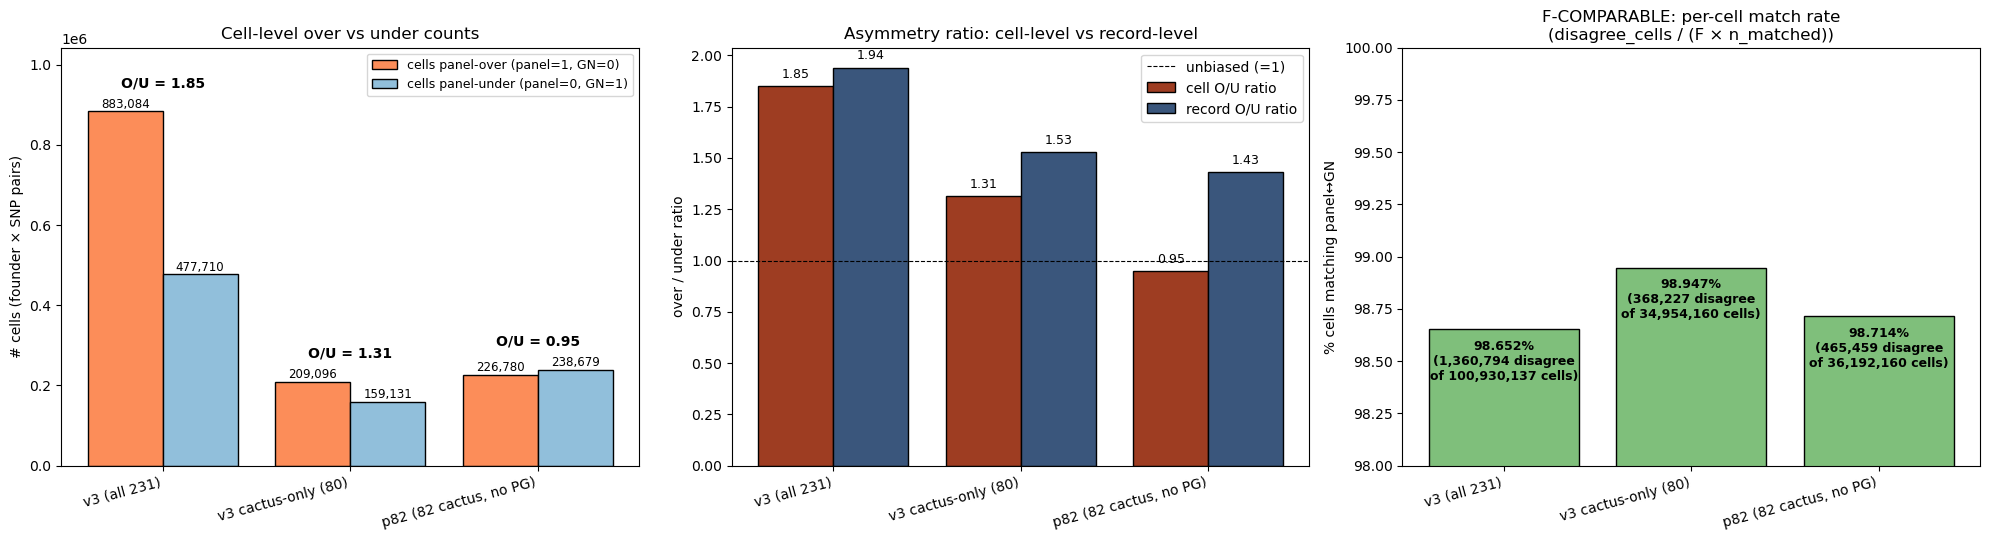

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# Left: stacked cell counts
ax = axes[0]
co = df['cells_over'].values
cu = df['cells_under'].values
ax.bar(x - 0.2, co, width=0.4, color='#fc8d59', label='cells panel-over (panel=1, GN=0)', edgecolor='black')
ax.bar(x + 0.2, cu, width=0.4, color='#91bfdb', label='cells panel-under (panel=0, GN=1)', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('# cells (founder × SNP pairs)')
ax.set_title('Cell-level over vs under counts')
for xi in range(len(labels)):
    ax.text(xi - 0.2, co[xi] + max(co.max(), cu.max())*0.01, f'{int(co[xi]):,}', ha='center', fontsize=8.5)
    ax.text(xi + 0.2, cu[xi] + max(co.max(), cu.max())*0.01, f'{int(cu[xi]):,}', ha='center', fontsize=8.5)
    ratio = co[xi] / max(cu[xi], 1)
    ax.text(xi, max(co[xi], cu[xi]) + max(co.max(), cu.max())*0.06,
            f'O/U = {ratio:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(co.max(), cu.max()) * 1.18)
ax.legend(loc='upper right', fontsize=9)

# Middle: ratios
ax = axes[1]
ax.bar(x - 0.2, df['cell_O_U_ratio'], width=0.4, color='#9e3d22', label='cell O/U ratio', edgecolor='black')
ax.bar(x + 0.2, df['rec_O_U_ratio'], width=0.4, color='#3a567c', label='record O/U ratio', edgecolor='black')
ax.axhline(1.0, color='black', linestyle='--', lw=0.8, label='unbiased (=1)')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('over / under ratio')
ax.set_title('Asymmetry ratio: cell-level vs record-level')
for xi, v in enumerate(df['cell_O_U_ratio']):
    ax.text(xi - 0.2, v + 0.04, f'{v:.2f}', ha='center', fontsize=9)
for xi, v in enumerate(df['rec_O_U_ratio']):
    ax.text(xi + 0.2, v + 0.04, f'{v:.2f}', ha='center', fontsize=9)
ax.legend()

# Right: F-COMPARABLE per-cell match rate
ax = axes[2]
match_pct = df['cell_match_pct'].values
disagree_pct = df['cell_disagree_pct'].values
bars = ax.bar(x, match_pct, color='#7fbf7b', edgecolor='black', label='cells matching')
ax.set_ylim(min(match_pct.min() - 0.5, 98), 100.0)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('% cells matching panel↔GN')
ax.set_title('F-COMPARABLE: per-cell match rate\n(disagree_cells / (F × n_matched))')
for xi in range(len(labels)):
    ax.text(xi, match_pct[xi] - 0.05, f'{match_pct[xi]:.3f}%\n({int(df["disagree_cells"].values[xi]):,} disagree\nof {int(df["total_cells"].values[xi]):,} cells)',
            ha='center', va='top', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


## Plot 4 — Mean cell-disagreement per record by direction

Reveals the "broad shallow over-call vs deep concentrated under-call" pattern in p82.


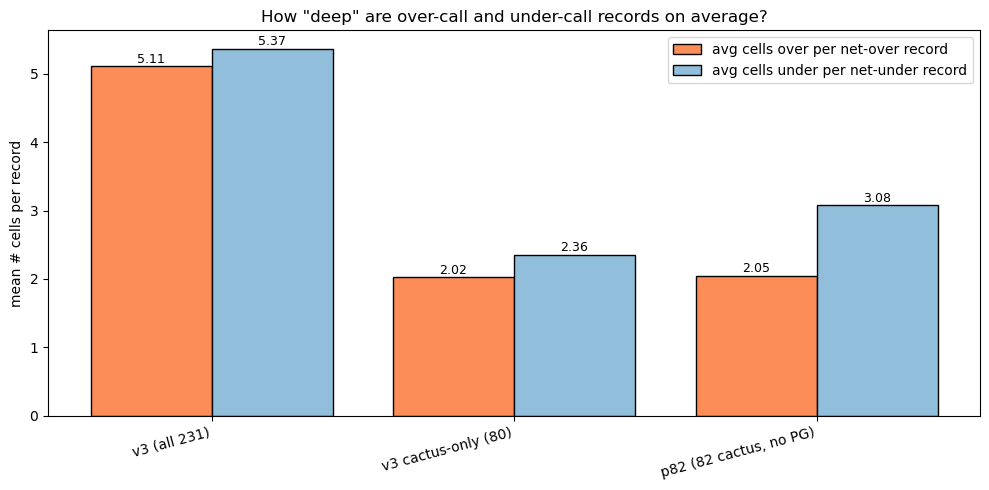

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
m_over  = df['mean_over_cells_per_over_record']
m_under = df['mean_under_cells_per_under_record']
ax.bar(x - 0.2, m_over, width=0.4, color='#fc8d59',
       label='avg cells over per net-over record', edgecolor='black')
ax.bar(x + 0.2, m_under, width=0.4, color='#91bfdb',
       label='avg cells under per net-under record', edgecolor='black')
for xi, v in enumerate(m_over):
    ax.text(xi - 0.2, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
for xi, v in enumerate(m_under):
    ax.text(xi + 0.2, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('mean # cells per record')
ax.set_title('How "deep" are over-call and under-call records on average?')
ax.legend()
plt.tight_layout()
plt.show()


## Plot 5 — Per-record carrier-AF: panel vs GN, POLYMORPHIC-in-panel only

For each panel, plot per-record carrier-AF (carriers / F_overlap) against GN's carrier-AF on the matched (chrom, pos, REF, ALT) intersection. **Filtered to records where the panel itself is polymorphic** (0 < panel_carriers < F) — i.e., we drop records where the variant is monomorphic in the panel subset, since those are uninformative for sub-panel-vs-GN comparisons.

**Discrete-grid aware**: both axes are integer multiples of 1/F (F=231 or 80). Plot uses `hist2d` with bin edges centered on `k/F` so each cell counts exact (panel_carriers, gn_carriers) pairs. Eliminates the hex-grid aliasing bands seen with `hexbin`.

**Why filter**: a SNP carried only by PG founders has 0 carriers in the cactus-only subset → carrier_AF=0/80=0. Without filtering, all such PG-only SNPs pile up at y=0 and look like systematic under-calling (which they are, but only because we removed the founders that would have carried them). Filtering isolates the apples-to-apples question: where the panel has variation, does it agree with GN on which founders carry it?


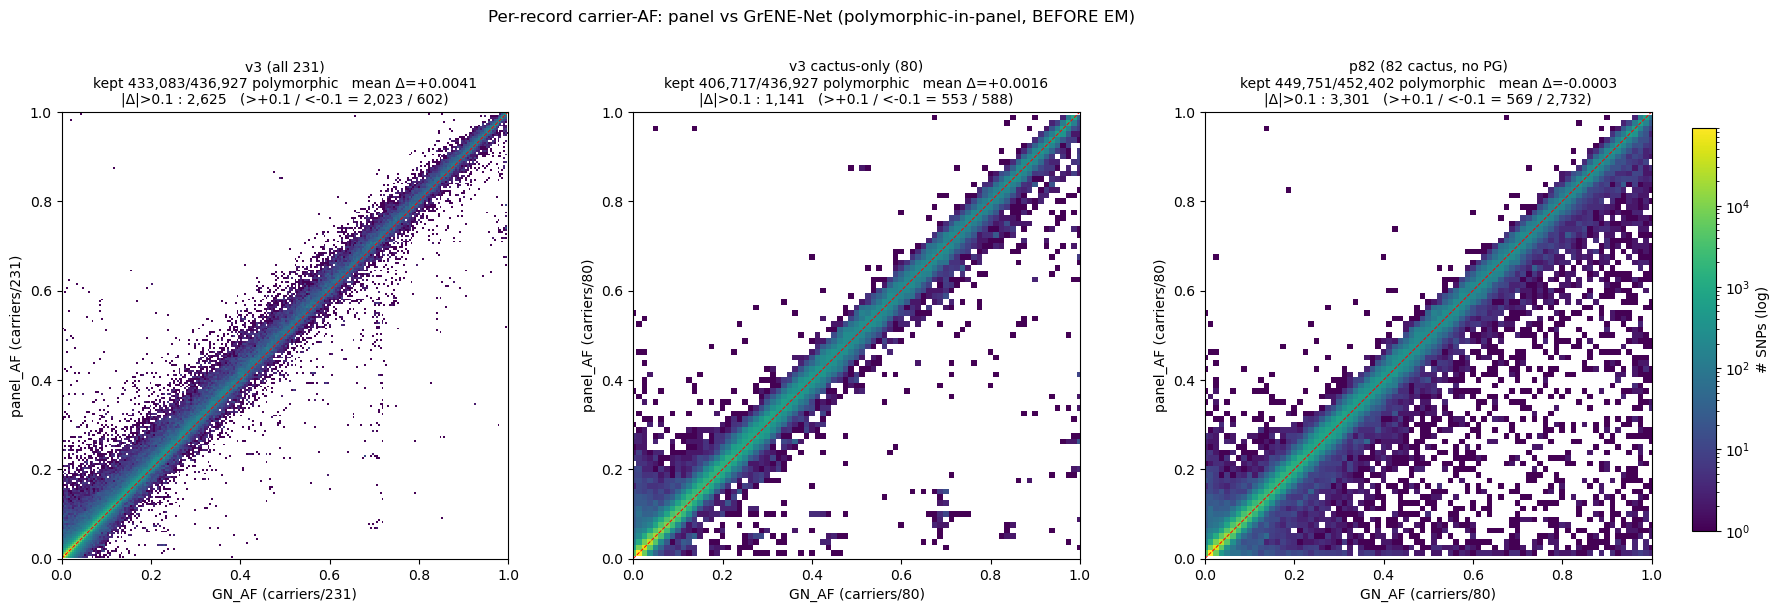

In [6]:
panel_specs = [
    ('v3 (all 231)',           ROOT/'scratch/per_record_af_v3.npz'),
    ('v3 cactus-only (80)',    ROOT/'scratch/per_record_af_v3_cactus_only.npz'),
    ('p82 (82 cactus, no PG)', ROOT/'scratch/per_record_af_p82.npz'),
]
missing = [p for _, p in panel_specs if not p.exists()]
if missing:
    print('Missing:'); [print(' ', p) for p in missing]
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6.2))
    last_im = None
    for ax, (lab, p) in zip(axes, panel_specs):
        z = np.load(p, allow_pickle=True)
        gn_af = z['gn_af']; panel_af = z['panel_af']
        F = int(z['F_overlap'])
        # Recover integer carrier counts (panel_af = carriers/F is exact)
        panel_carriers = np.round(panel_af * F).astype(int)
        gn_carriers    = np.round(gn_af    * F).astype(int)
        # Polymorphic-in-panel filter
        keep = (panel_carriers > 0) & (panel_carriers < F)
        n_total = len(panel_carriers); n_keep = int(keep.sum())
        gn_af_f = gn_af[keep]; panel_af_f = panel_af[keep]
        diff_f  = panel_af_f - gn_af_f
        # Discrete-aligned bin edges: F+1 cells, each centered on k/F
        edges = (np.arange(F + 2) - 0.5) / F
        H, xe, ye, im = ax.hist2d(gn_af_f, panel_af_f, bins=[edges, edges],
                                   cmap='viridis', norm=LogNorm(vmin=1))
        last_im = im
        ax.plot([0,1],[0,1], 'r--', lw=0.7)
        ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
        ax.set_xlabel(f'GN_AF (carriers/{F})')
        ax.set_ylabel(f'panel_AF (carriers/{F})')
        ax.set_title(
            f'{lab}\n'
            f'kept {n_keep:,}/{n_total:,} polymorphic   '
            f'mean Δ={diff_f.mean():+.4f}\n'
            f'|Δ|>0.1 : {(np.abs(diff_f)>0.1).sum():,}   '
            f'(>+0.1 / <-0.1 = {(diff_f>0.1).sum():,} / {(diff_f<-0.1).sum():,})',
            fontsize=10
        )
    # single colorbar on the right
    fig.subplots_adjust(right=0.92, wspace=0.28)
    cax = fig.add_axes([0.94, 0.18, 0.012, 0.65])
    fig.colorbar(last_im, cax=cax, label='# SNPs (log)')
    fig.suptitle('Per-record carrier-AF: panel vs GrENE-Net (polymorphic-in-panel, BEFORE EM)',
                 y=1.02, fontsize=12)
    plt.show()


## Plot 6 — FAIR comparison: v3 cactus-only vs p82 on the shared variant set

Plot 5 made v3-cactus-only and p82 look very different. That's mostly a **variant-set artifact**: each panel matches a different ~440K subset of GN. Here we restrict to the **357,808 (chrom, pos, ref, alt) keys present in BOTH panels' GN-matched record sets**, then evaluate both panels on the **same 80 cactus founders** (verified earlier: identical sets) using the **same GN truth**.

If the pipelines agree on this fair set, the Plot-5 difference is variant-coverage, not pipeline quality. If they still differ, it's a real per-(founder, SNP) call disagreement.

Source: `scratch/per_record_af_fair_v3c_vs_p82.npz` from the in-script triple intersection.


shared (chrom,pos,ref,alt) keys: 360,031   polymorphic-in-both: 357,808


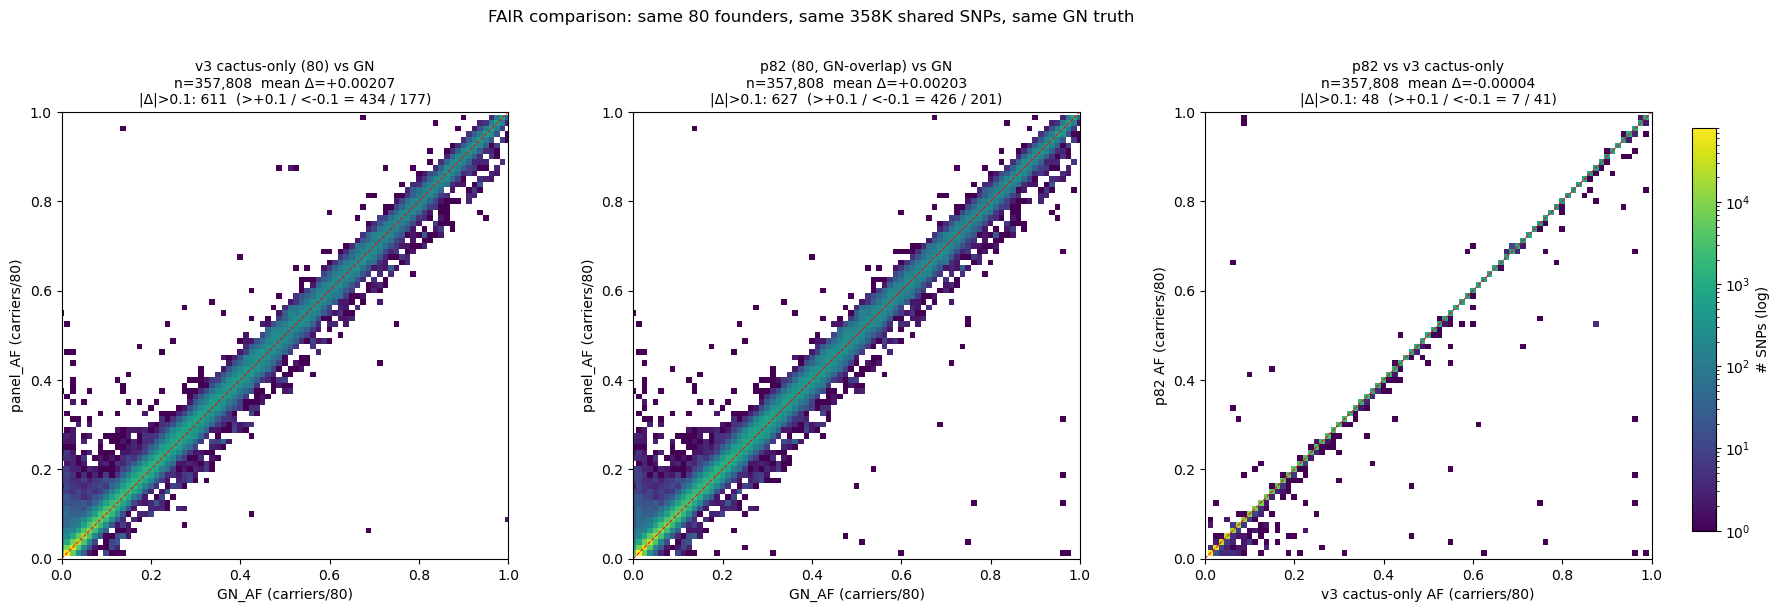

In [7]:
z = np.load(ROOT/'scratch/per_record_af_fair_v3c_vs_p82.npz', allow_pickle=True)
v3c_af = z['v3c_af']; p82_af = z['p82_af']; gn_af = z['gn_af']
keep = z['keep'].astype(bool); F = int(z['F'])
n_total = int(z['n_total']); n_keep = int(keep.sum())
print(f'shared (chrom,pos,ref,alt) keys: {n_total:,}   polymorphic-in-both: {n_keep:,}')

edges = (np.arange(F + 2) - 0.5) / F
fig, axes = plt.subplots(1, 3, figsize=(20, 6.2))
panels = [
    ('v3 cactus-only (80) vs GN', v3c_af, gn_af),
    ('p82 (80, GN-overlap) vs GN', p82_af, gn_af),
    ('p82 vs v3 cactus-only',     p82_af, v3c_af),
]
last_im = None
for ax, (lab, y_af, x_af) in zip(axes, panels):
    diff = y_af[keep] - x_af[keep]
    H, xe, ye, im = ax.hist2d(x_af[keep], y_af[keep], bins=[edges, edges],
                               cmap='viridis', norm=LogNorm(vmin=1))
    last_im = im
    ax.plot([0,1],[0,1],'r--', lw=0.7)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    if 'vs GN' in lab:
        ax.set_xlabel(f'GN_AF (carriers/{F})')
        ax.set_ylabel(f'panel_AF (carriers/{F})')
    else:
        ax.set_xlabel(f'v3 cactus-only AF (carriers/{F})')
        ax.set_ylabel(f'p82 AF (carriers/{F})')
    ax.set_title(
        f'{lab}\n'
        f'n={n_keep:,}  mean Δ={diff.mean():+.5f}\n'
        f'|Δ|>0.1: {(np.abs(diff)>0.1).sum():,}  '
        f'(>+0.1 / <-0.1 = {(diff>0.1).sum():,} / {(diff<-0.1).sum():,})',
        fontsize=10
    )
fig.subplots_adjust(right=0.92, wspace=0.28)
cax = fig.add_axes([0.94, 0.18, 0.012, 0.65])
fig.colorbar(last_im, cax=cax, label='# SNPs (log)')
fig.suptitle('FAIR comparison: same 80 founders, same 358K shared SNPs, same GN truth',
             y=1.02, fontsize=12)
plt.show()


## Bottom line — what each panel says

| panel | F | exact match % (per-record) | per-cell match % (F-comparable) | cell O/U | record O/U | interpretation |
|---|---|---|---|---|---|---|
| **p82 (cactus only, no PG)** | 80 | 51.7% | (see Plot 3 right) | **0.95** | 1.43 | **Symmetric at cell level** — cactus alone calls carriers ~as often as GN. Long-read assembly is NOT the source of v3's over-call asymmetry. |
| v3 cactus-only (in v3 pipeline) | 80 | 54.4% | (see Plot 3 right) | 1.31 | 1.53 | Mild over-call. Comes from v3 build steps (atomization, merge with PG). |
| **v3 (all 231)** | 231 | 33.2% | (see Plot 3 right) | **1.85** | 1.94 | Strongest over-call. The 151 PG founders' addition pushes the ratio from 1.31 → 1.85. |

**Caveat repeated**: the 33% vs 54% gap on "exact match per-record" is partly a denominator artifact — v3 has 231 cells per record vs 80 for the cactus-only restrictions. The **per-cell match %** in Plot 3 (right) is the apples-to-apples metric: it normalizes by F.

**The 1.85× cell-level over-call in production v3 is driven by PanGenie genotyping, not by cactus/long-read discovery.** Pure cactus (p82) is balanced at the cell level (0.95). Each step downstream (cactus-only-in-v3 → all-of-v3) progressively introduces over-call asymmetry.

**The record-level O/U is always > cell-level O/U.** Over-calls are spread across many records (each adding a few cells), while under-calls are concentrated in fewer records (each losing many founders). p82 shows this most cleanly: cell ratio 0.95 (balanced) but record ratio 1.43 (more records lean over-call).


---

### Plot 6 takeaway (fair comparison)

On 357,808 SNPs present in BOTH v3-cactus-only and p82 GN-matched sets, evaluated on the same 80 founders against the same GN truth:

- v3 cactus-only: mean Δ = +0.00207, |Δ|>0.1 in 611 records (434 over / 177 under)
- p82:            mean Δ = +0.00203, |Δ|>0.1 in 627 records (426 over / 201 under)

**The two pipelines agree at essentially the same level on shared variants.** The dramatic difference in Plot 5 was driven by the ~95K records each panel has that the other doesn't (p82 has more cactus-discovered singletons; v3 has more variants from the PG merge surviving). The PIPELINE quality (cactus build → atomization → per-founder GT call) is comparable; only the variant-set COVERAGE differs.
